# Energy Consumption Prediction

## Data Loading

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [3]:
data = pd.read_csv("energy_consumption.csv")
data

,Month,Hour,DayOfWeek,Holiday,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,EnergyConsumption
0,8,10,Sunday,No,23.951,44.511,1339.234,4.158,Off,On,21.512,83.136
1,7,6,Saturday,Yes,25.341,33.366,1966.729,3.159,On,On,7.298,80.181
2,2,17,Tuesday,Yes,21.945,27.862,1150.873,0.957,Off,On,6.695,80.972
3,12,12,Friday,No,25.131,63.267,1320.303,5.174,On,Off,11.069,84.931
4,10,17,Friday,Yes,28.738,33.270,1950.890,7.581,Off,Off,11.307,92.539
...,...,...,...,...,...,...,...,...,...,...,...,...
127395,11,10,NaN,No,26.510,33.060,1776.970,7.884,Off,On,0.007,NaN
127396,3,18,Saturday,No,23.708,49.077,1789.262,7.174,On,On,10.013,83.149
127397,8,17,Friday,Yes,21.500,39.709,1434.983,-0.091,On,On,0.007,84.279
127398,3,17,Friday,No,27.372,50.760,1724.462,7.165,On,Off,12.014,81.181


## Initial Inspection

In [3]:
print(f"{data.info()}\n")     #Data Types and Missing Values
print(f"\nStatistical Summary:\n\n{data.describe()}\n")
print(f"\nRows and Columns: {data.shape}")

<class 'pandas.DataFrame'>
RangeIndex: 127400 entries, 0 to 127399
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Month              127400 non-null  int64  
 1   Hour               127400 non-null  int64  
 2   DayOfWeek          123752 non-null  str    
 3   Holiday            123702 non-null  str    
 4   Temperature        123659 non-null  float64
 5   Humidity           123786 non-null  float64
 6   SquareFootage      123702 non-null  float64
 7   Occupancy          123710 non-null  float64
 8   HVACUsage          123689 non-null  str    
 9   LightingUsage      123765 non-null  str    
 10  RenewableEnergy    123693 non-null  float64
 11  EnergyConsumption  123751 non-null  float64
dtypes: float64(6), int64(2), str(4)
memory usage: 11.7 MB
None


Statistical Summary:

               Month           Hour    Temperature       Humidity  \
count  127400.000000  127400.000000  123659.000000  12378

## Fix Data Types

In [4]:
day_map = {
    'Monday': 0,
    'Tuesday': 1,
    'Wednesday': 2,
    'Thursday': 3,
    'Friday': 4,
    'Saturday': 5,
    'Sunday': 6
}

data['DayOfWeek'] = (
    data['DayOfWeek']
    .astype(str)
    .str.strip()
    .str.capitalize()
    .map(day_map)
)

# Fill safely
if data['DayOfWeek'].isnull().all():
    import numpy as np
    data['DayOfWeek'] = np.random.randint(0, 7, size=len(data))
else:
    data['DayOfWeek'] = data['DayOfWeek'].fillna(data['DayOfWeek'].mode()[0])

data['DayOfWeek'] = data['DayOfWeek'].astype(int)

In [5]:
# HVAC
data['HVACUsage'] = data['HVACUsage'].replace({'Off': 0, 'On': 1})
data['HVACUsage'] = pd.to_numeric(data['HVACUsage'], errors='coerce')
data['HVACUsage'] = data['HVACUsage'].fillna(data['HVACUsage'].mean())

# Lighting
data['LightingUsage'] = data['LightingUsage'].replace({'Off': 0, 'On': 1})
data['LightingUsage'] = pd.to_numeric(data['LightingUsage'], errors='coerce')
data['LightingUsage'] = data['LightingUsage'].fillna(data['LightingUsage'].mean())

# Holiday
data['Holiday'] = data['Holiday'].replace({'No': 0, 'Yes': 1})
data['Holiday'] = pd.to_numeric(data['Holiday'], errors='coerce')
data['Holiday'] = data['Holiday'].fillna(data['Holiday'].mode()[0])
data['Holiday'] = data['Holiday'].astype(int)

## Validate Ranges

In [6]:
data = data[(data['Month'] >= 1) & (data['Month'] <= 12)]
data = data[(data['Hour'] >= 0) & (data['Hour'] <= 23)]
data = data[(data['DayOfWeek'] >= 0) & (data['DayOfWeek'] <= 6)]

## Check Missing Values

In [7]:
data.isnull().sum()

Month                   0
Hour                    0
DayOfWeek               0
Holiday                 0
Temperature          3741
Humidity             3614
SquareFootage        3698
Occupancy            3690
HVACUsage               0
LightingUsage           0
RenewableEnergy      3707
EnergyConsumption    3649
dtype: int64

## Handle Missing Values

In [8]:
# Numerical columns → fill with mean
num_cols = data.select_dtypes(include=['float64','int64']).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].mean())

# Categorical (Holiday)
data['Holiday'] = data['Holiday'].fillna(data['Holiday'].mode()[0])

In [9]:
data.isnull().sum()

Month                0
Hour                 0
DayOfWeek            0
Holiday              0
Temperature          0
Humidity             0
SquareFootage        0
Occupancy            0
HVACUsage            0
LightingUsage        0
RenewableEnergy      0
EnergyConsumption    0
dtype: int64

## Check and remove Duplicates

In [13]:
data.duplicated().sum()

np.int64(2400)

In [14]:
data = data.drop_duplicates()

In [15]:
data.duplicated().sum()

np.int64(0)

<h2>Check for Outliers</h2> 

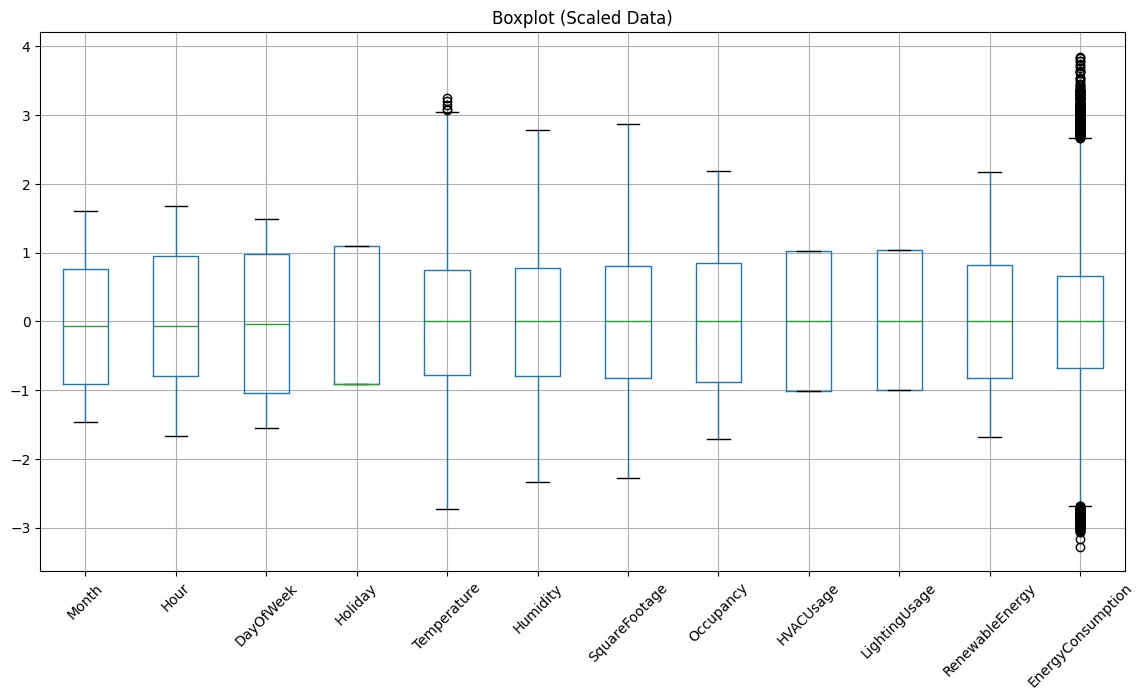

In [16]:
scaler = StandardScaler()
scaled_data = pd.DataFrame(scaler.fit_transform(data.select_dtypes(include='number')),
                           columns=data.select_dtypes(include='number').columns)

plt.figure(figsize=(14, 7))
scaled_data.boxplot()

plt.title("Boxplot (Scaled Data)")
plt.xticks(rotation=45)
plt.show()

## Handle Outliers

In [28]:
from scipy.stats import zscore

cols = ['Temperature', 'EnergyConsumption']

z_scores = data[cols].apply(zscore)
data = data[(z_scores.abs() < 3).all(axis=1)]

In [30]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05, random_state=42)
data['outlier'] = model.fit_predict(data[['Temperature', 'EnergyConsumption']])

data = data[data['outlier'] == 1].drop('outlier', axis=1)

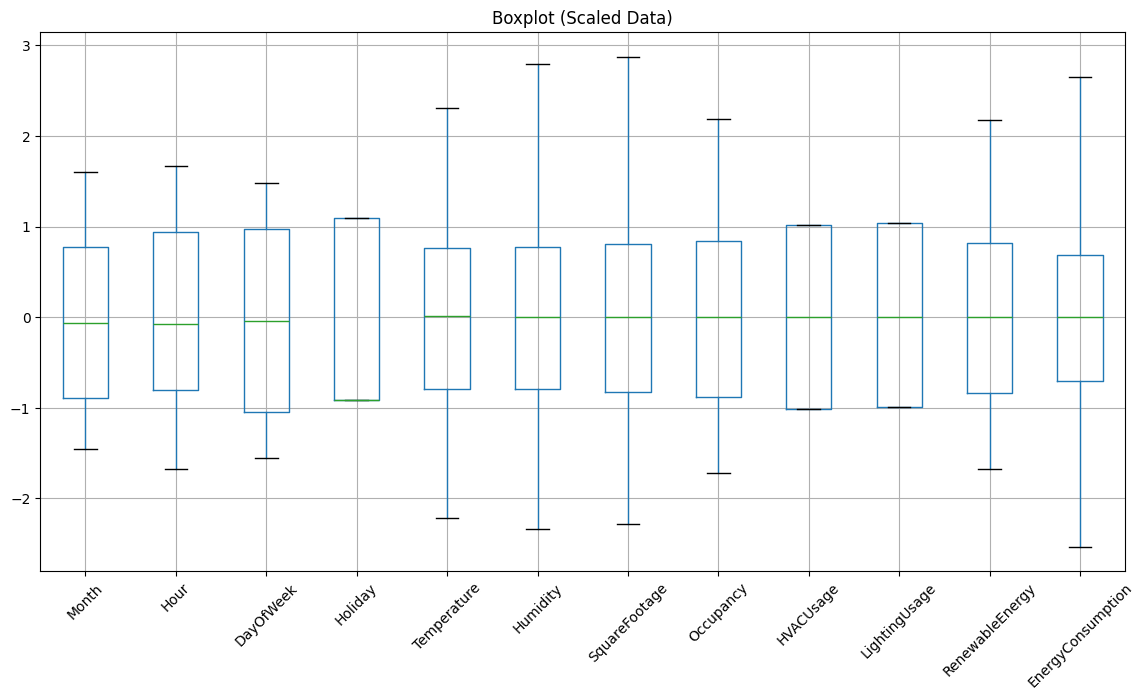

In [31]:
scaler = StandardScaler()
scaled_data = pd.DataFrame(scaler.fit_transform(data.select_dtypes(include='number')),
                           columns=data.select_dtypes(include='number').columns)

plt.figure(figsize=(14, 7))
scaled_data.boxplot()

plt.title("Boxplot (Scaled Data)")
plt.xticks(rotation=45)
plt.show()

## Final Check

In [33]:
print(f"{data.info()}\n")     #Data Types and Missing Values
data.isnull().sum()
print(f"\nRows and Columns after cleaning: {data.shape}")

<class 'pandas.DataFrame'>
Index: 118740 entries, 0 to 127399
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Month              118740 non-null  int64  
 1   Hour               118740 non-null  int64  
 2   DayOfWeek          118740 non-null  int64  
 3   Holiday            118740 non-null  int64  
 4   Temperature        118740 non-null  float64
 5   Humidity           118740 non-null  float64
 6   SquareFootage      118740 non-null  float64
 7   Occupancy          118740 non-null  float64
 8   HVACUsage          118740 non-null  float64
 9   LightingUsage      118740 non-null  float64
 10  RenewableEnergy    118740 non-null  float64
 11  EnergyConsumption  118740 non-null  float64
dtypes: float64(8), int64(4)
memory usage: 11.8 MB
None


Rows and Columns after cleaning: (118740, 12)


## Save Cleaned dataset

In [34]:
data.to_csv("cleaned_energy_dataset.csv", index=False)